In [1]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_excel('C:/Users/JOHN/Desktop/Sales Performance Analysis Project on Python.xlsx')

In [5]:
data

,OrderID,OrderDate,Region,Salesperson,ProductName,Sales
0,1001,2023-01-01,East,Alice,Laptop,1200
1,1002,2023-01-16,West,Bob,Tablet,800
2,1003,2023-01-31,North,Charlie,Monitor,450
3,1004,2023-02-15,South,David,Printer,700
4,1005,2023-03-02,East,Eve,Laptop,1300
5,1006,2023-03-17,West,Frank,Monitor,470
6,1007,2023-04-01,North,Grace,Tablet,820
7,1008,2023-04-16,South,Heidi,Printer,750
8,1009,2023-05-01,East,Ivan,Laptop,1100
9,1010,2023-05-16,West,Judy,Monitor,490


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      10 non-null     int64         
 1   OrderDate    10 non-null     datetime64[ns]
 2   Region       10 non-null     object        
 3   Salesperson  10 non-null     object        
 4   ProductName  10 non-null     object        
 5   Sales        10 non-null     int64         
 6   Month        10 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 692.0+ bytes


In [22]:
data.describe()

,OrderID,OrderDate,Sales
count,10.00000,10,10.0000
mean,1005.50000,2023-03-09 12:00:00,808.0000
min,1001.00000,2023-01-01 00:00:00,450.0000
25%,1003.25000,2023-02-03 18:00:00,542.5000
50%,1005.50000,2023-03-09 12:00:00,775.0000
75%,1007.75000,2023-04-12 06:00:00,1030.0000
max,1010.00000,2023-05-16 00:00:00,1300.0000
std,3.02765,NaN,305.4614


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'OrderID': [1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010],
    'OrderDate': pd.to_datetime([
        "2023-01-01", "2023-01-16", "2023-01-31", "2023-02-15", "2023-03-02",
        "2023-03-17", "2023-04-01", "2023-04-16", "2023-05-01", "2023-05-16"
    ]),
    'Region': ['East', 'West', 'North', 'South', 'East', 'West', 'North', 'South', 'East', 'West'],
    'Salesperson': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'ProductName': ['Laptop', 'Tablet', 'Monitor', 'Printer', 'Laptop', 'Monitor', 'Tablet', 'Printer', 'Laptop', 'Monitor'],
    'Sales': [1200, 800, 450, 700, 1300, 470, 820, 750, 1100, 490]
}
data = pd.DataFrame(data)


# Top-Selling Products

In [26]:
# Group by ProductName & sum Sales & Sort by Ascending
top_products = data.groupby('ProductName')['Sales'].sum().sort_values(ascending=False)
print(top_products)

ProductName
Laptop     3600
Tablet     1620
Printer    1450
Monitor    1410
Name: Sales, dtype: int64


# Bar Chart Plot For Top Selling Products

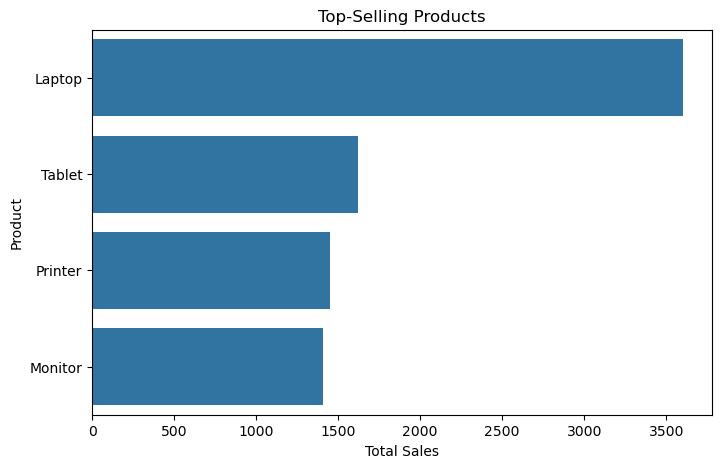

In [62]:
plt.figure(figsize=(8, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.show()


# Monthly Sales Trends

In [28]:
data["OrderDate"] = pd.to_datetime(data["OrderDate"]) 
data["Month"] = data["OrderDate"].dt.strftime("%Y-%m")  

monthly_trends = data.groupby("Month")["Sales"].sum().reset_index()

print(monthly_trends)


     Month  Sales
0  2023-01   2450
1  2023-02    700
2  2023-03   1770
3  2023-04   1570
4  2023-05   1590


# Line plot for Monthly Sales Trends

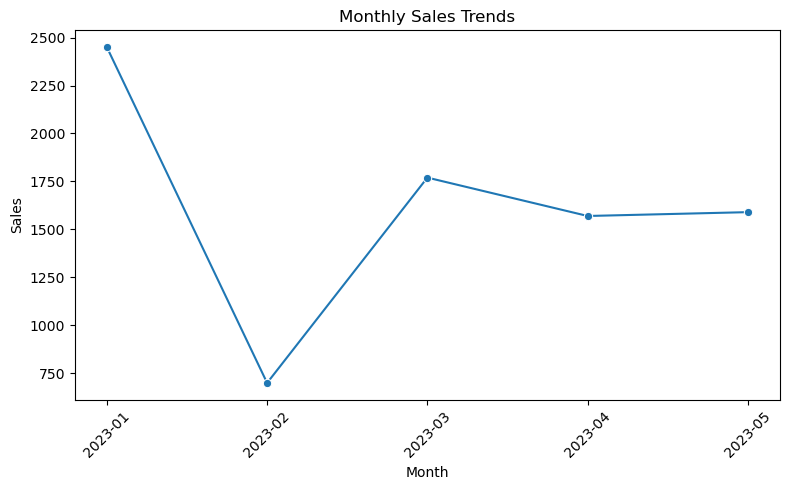

In [41]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Regional Sales Performance

In [30]:
regional_sales = data.groupby("Region")["Sales"].sum().reset_index()

print(regional_sales)


  Region  Sales
0   East   3600
1  North   1270
2  South   1450
3   West   1760


In [32]:
# Group by Region and Month
regional_monthly_sales = data.groupby(["Region", "Month"])["Sales"].sum().reset_index()
print(regional_monthly_sales)

  Region    Month  Sales
0   East  2023-01   1200
1   East  2023-03   1300
2   East  2023-05   1100
3  North  2023-01    450
4  North  2023-04    820
5  South  2023-02    700
6  South  2023-04    750
7   West  2023-01    800
8   West  2023-03    470
9   West  2023-05    490


# Bar chart for Regional Sales Performance

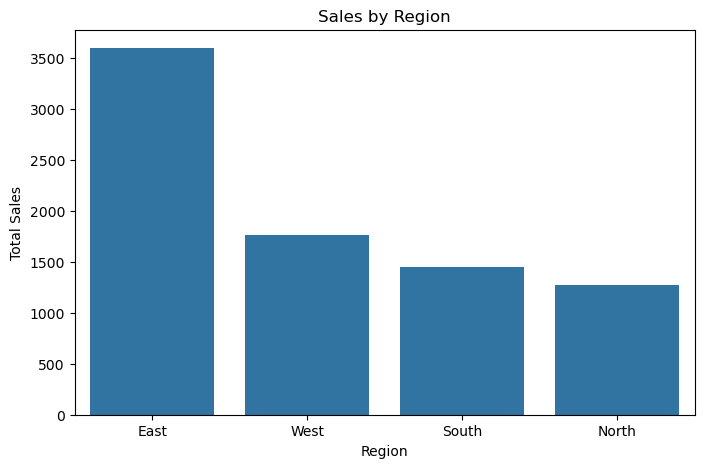

In [64]:
regional_sales = data.groupby('Region')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=regional_sales.index, y=regional_sales.values)
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()


# Conclusion